<a href="https://colab.research.google.com/github/MohammadJoenathan/Klasifikasi-Citra-Kupu-Kupu-Menggunakan-K-Means/blob/main/2218060MohammadJoenathanKlasifikasiCitraKupuKupuMetodeK_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Menghubungkan Google Colab Dengan Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2. Import Library Yang Dibutuhkan

In [18]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from skimage.feature import local_binary_pattern
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 3. Set Path Folder Dataset Dari Google Drive

In [5]:
dataset_path = "/content/drive/MyDrive/Colab Notebooks/ComVisUTS/datasetcitrakupukupu"

# 4. Membuat Fungsi Ekstraksi Fitur Tekstur Menggunakan LBP

In [6]:
def extract_lbp_features(image, radius=2, n_points=16):
    # ubah gambar menjadi grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # hitung lbp (uniform membuat hasil lebih stabil)
    lbp = local_binary_pattern(gray, n_points, radius, method="uniform")

    # buat histogram dari hasil lbp
    (hist, _) = np.histogram(lbp.ravel(),
                             bins=np.arange(0, n_points + 3),
                             range=(0, n_points + 2))

    # normalisasi histogram
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)

    return hist

# 5. Membaca Citra Dan Melakukan Ekstraksi Fitur LBP

In [7]:
data = []
filenames = []

images = os.listdir(dataset_path)

for img_name in tqdm(images, desc="extracting lbp features"):
    img_path = os.path.join(dataset_path, img_name)

    # baca citra
    img = cv2.imread(img_path)

    # skip jika gambar rusak
    if img is None:
        continue

    # resize agar semua gambar seragam
    img = cv2.resize(img, (128, 128))

    # ekstraksi fitur lbp
    features = extract_lbp_features(img)

    data.append(features)
    filenames.append(img_name)

X = np.array(data)

print("jumlah data fitur:", X.shape)

extracting lbp features: 100%|██████████| 1000/1000 [01:22<00:00, 12.05it/s]

jumlah data fitur: (1000, 18)


#6. Menyimpan Hasil Ekstraksi Fitur Ke CSV Dan Excel

In [8]:
df_features = pd.DataFrame(X)
df_features.insert(0, "filename", filenames)

df_features.head()

output_csv = "/content/drive/MyDrive/Colab Notebooks/ComVisUTS/fitur_lbp_kupukupu.csv"
output_excel = "/content/drive/MyDrive/Colab Notebooks/ComVisUTS/fitur_lbp_kupukupu.xlsx"

df_features.to_csv(output_csv, index=False)
df_features.to_excel(output_excel, index=False)

print("fitur lbp berhasil disimpan:")
print(output_csv)
print(output_excel)

fitur lbp berhasil disimpan:
/content/drive/MyDrive/Colab Notebooks/ComVisUTS/fitur_lbp_kupukupu.csv
/content/drive/MyDrive/Colab Notebooks/ComVisUTS/fitur_lbp_kupukupu.xlsx


#7. Normalisasi Fitur Sebelum Clustering

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#8. Menentukan Jumlah Cluster Terbaik

In [10]:
sil_scores = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, cluster_labels)
    sil_scores.append(score)

    print(f"jumlah cluster = {k}, silhouette score = {score:.4f}")

jumlah cluster = 2, silhouette score = 0.2978
jumlah cluster = 3, silhouette score = 0.3167
jumlah cluster = 4, silhouette score = 0.2273
jumlah cluster = 5, silhouette score = 0.2161
jumlah cluster = 6, silhouette score = 0.1956
jumlah cluster = 7, silhouette score = 0.1909
jumlah cluster = 8, silhouette score = 0.1996


#9. Training K-Means Clustering

In [11]:
k_best = 4

kmeans_model = KMeans(n_clusters=k_best, random_state=42, n_init=10)
clusters = kmeans_model.fit_predict(X_scaled)

print("clustering selesai, jumlah cluster:", k_best)

clustering selesai, jumlah cluster: 4


#10. Menambahkan Hasil Cluster Ke Dataframe

In [12]:
df_features["cluster"] = clusters
df_features.head()
print(df_features["cluster"].value_counts())

cluster
0    347
2    341
1    268
3     44
Name: count, dtype: int64


#11. Visualisasi Hasil

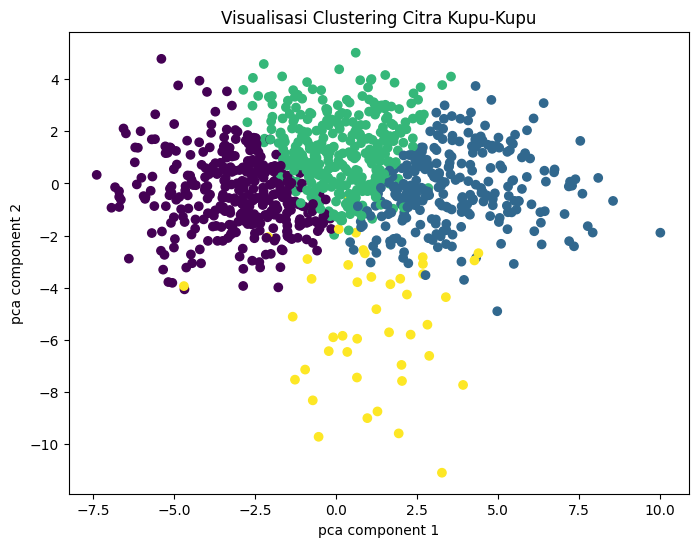

In [16]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("Visualisasi Clustering Citra Kupu-Kupu")
plt.xlabel("pca component 1")
plt.ylabel("pca component 2")
plt.show()

#12. Simpan Hasil Clustering Ke CSV Dan Excel

In [13]:
output_cluster_csv = "/content/drive/MyDrive/Colab Notebooks/ComVisUTS/hasil_cluster_kupukupu.csv"
output_cluster_excel = "/content/drive/MyDrive/Colab Notebooks/ComVisUTS/hasil_cluster_kupukupu.xlsx"

df_features.to_csv(output_cluster_csv, index=False)
df_features.to_excel(output_cluster_excel, index=False)

print("hasil clustering berhasil disimpan:")
print(output_cluster_csv)
print(output_cluster_excel)

hasil clustering berhasil disimpan:
/content/drive/MyDrive/Colab Notebooks/ComVisUTS/hasil_cluster_kupukupu.csv
/content/drive/MyDrive/Colab Notebooks/ComVisUTS/hasil_cluster_kupukupu.xlsx
